In [1]:
import os, re
import yaml

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
RAW_PATH = os.path.join('.', '.data', 'raw')
CROPS_PATH = os.path.join('.', '.data', 'crops')
DATASET_PATH = os.path.join('.', '.data', 'crop-dataset')

In [3]:
data_info = yaml.load(open(os.path.join(RAW_PATH, 'raw.yaml')), yaml.SafeLoader)

names: list[str] = data_info['names']
nc: int = data_info['nc']

'# Classes: ' + str(nc), ' - '.join(names)

('# Classes: 10',
 'banded_chlorosis - brown_spot - brownrust - dried_leaves - grassy_shoot - pokkah_boeng - sett_rot - smut - viral_disease - yellow_leaf')

In [4]:
rows = list()

for name in names:
  for img in os.listdir(os.path.join(CROPS_PATH, name)):
    m = re.match(r"(.+?)_(\d+)_(\d+)_(\d+).jpg", img)

    if not m:
      pass

    rows.append(dict(
      image_class=m.group(1), 
      video_id=int(m.group(2)),
      frame_id=int(m.group(3)),
      crop_id=int(m.group(4)),
      path=img
    ))

df = pd.DataFrame(rows)

df.sample(8)

,image_class,video_id,frame_id,crop_id,path
910,brown_spot,1962,395,0,brown_spot_1962_395_0.jpg
1620,brownrust,1463,87,3,brownrust_1463_87_3.jpg
2095,dried_leaves,235,53,7,dried_leaves_235_53_7.jpg
2286,dried_leaves,274,53,6,dried_leaves_274_53_6.jpg
287,brown_spot,3099,378,1,brown_spot_3099_378_1.jpg
627,brown_spot,2792,385,1,brown_spot_2792_385_1.jpg
2561,grassy_shoot,3351,109,1,grassy_shoot_3351_109_1.jpg
3751,sett_rot,4030,156,0,sett_rot_4030_156_0.jpg


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4479 entries, 0 to 4478
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   image_class  4479 non-null   object
 1   video_id     4479 non-null   int64 
 2   frame_id     4479 non-null   int64 
 3   crop_id      4479 non-null   int64 
 4   path         4479 non-null   object
dtypes: int64(3), object(2)
memory usage: 175.1+ KB


In [6]:
video_class = (
    df.groupby("video_id")["image_class"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

train_videos, temp_videos = train_test_split(
    video_class,
    test_size=0.3,
    stratify=video_class["image_class"],
    random_state=42,
)

val_videos, test_videos = train_test_split(
    temp_videos,
    test_size=0.5,
    stratify=temp_videos["image_class"],
    random_state=42,
)

train_df = df[df["video_id"].isin(train_videos["video_id"])]
val_df = df[df["video_id"].isin(val_videos["video_id"])]
test_df = df[df["video_id"].isin(test_videos["video_id"])]

In [7]:
def plot_images_distribution(df: pd.DataFrame, title: str ="Class Distribution"):
    dist_full = df["image_class"].value_counts().sort_index()
    dist_videos = df.groupby("image_class")["video_id"].nunique()

    n_plots =  2

    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5), sharey=False)

    fig.suptitle(title)

    for data, ax, title in [
        (dist_full, axes[0], "Frames"),
        (dist_videos, axes[1], "Videos"),
    ]:
        data.plot(kind="bar", ax=ax, title=title, legend=False)

        mean_val = data.mean()
        min_val = data.min()

        line_mean = ax.axhline(mean_val, color="r", linestyle="--")
        line_min  = ax.axhline(min_val,  color="g", linestyle=":")

        x_pos = len(data) - 0.25
        ax.text(x_pos, mean_val, f"{mean_val:.1f}", color="r", va="bottom", ha="left")
        ax.text(x_pos, min_val,  f"{min_val}", color="g", va="bottom", ha="left")

        ax.set_xlabel("Class")
        ax.set_ylabel("Count")

        ax.legend([line_mean, line_min], [f"mean = {mean_val:.1f}", f"min = {min_val}"])

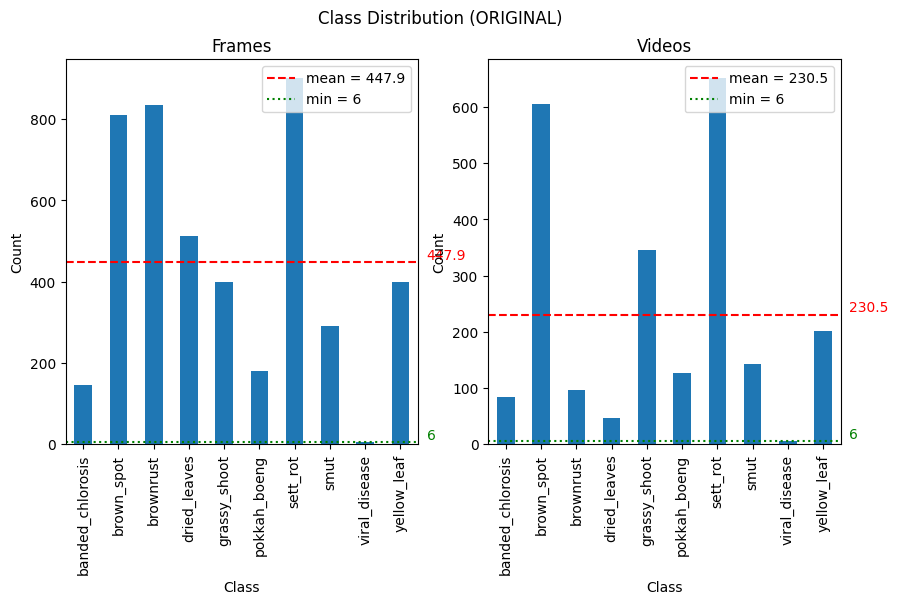

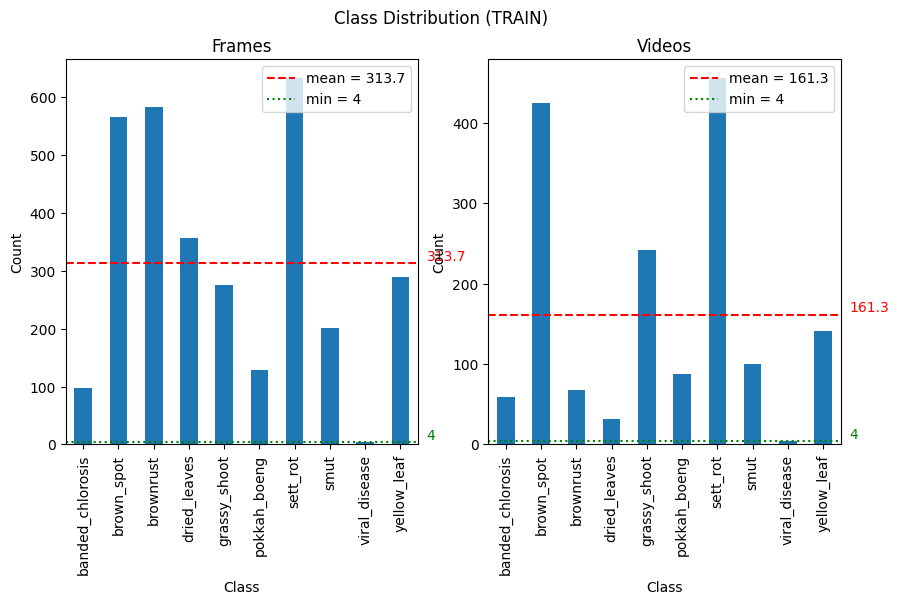

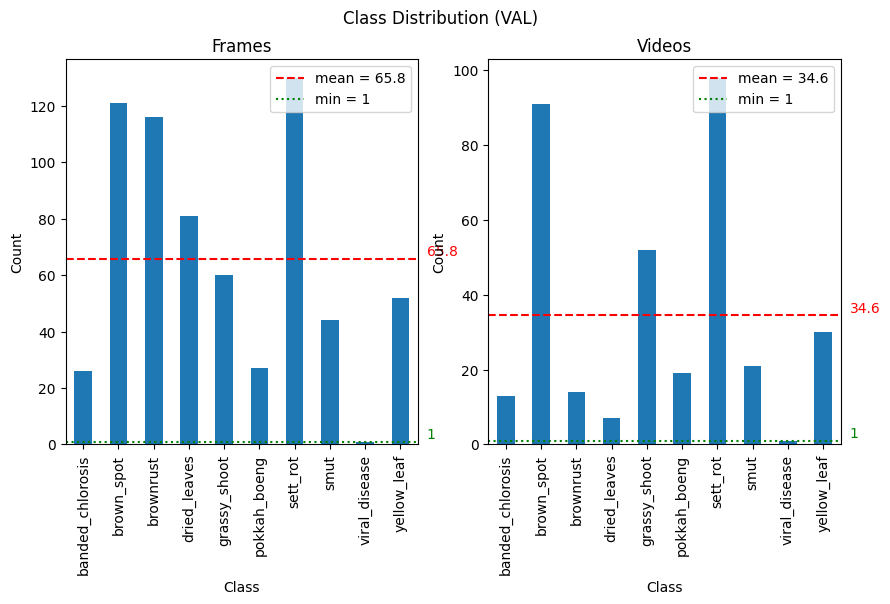

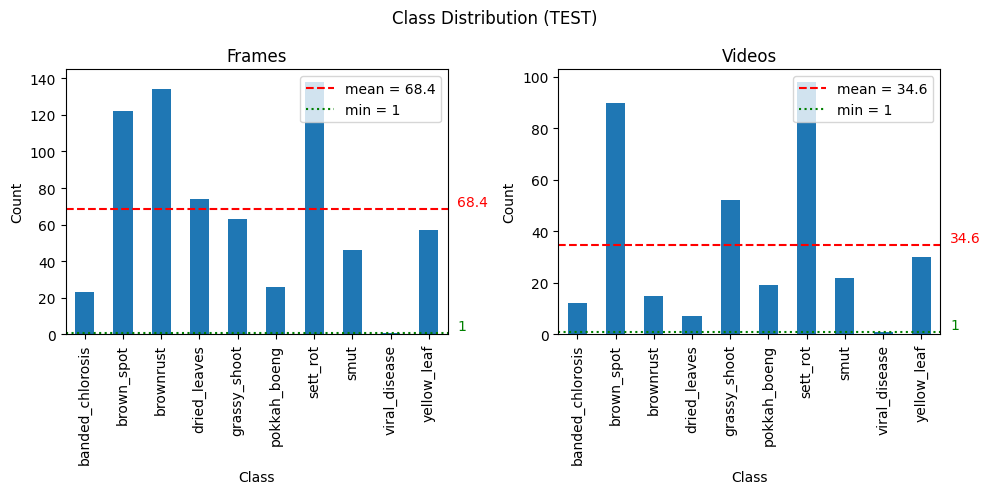

In [8]:
plot_images_distribution(df=df, title="Class Distribution (ORIGINAL)")
plot_images_distribution(df=train_df, title="Class Distribution (TRAIN)")
plot_images_distribution(df=val_df, title="Class Distribution (VAL)")
plot_images_distribution(df=test_df, title="Class Distribution (TEST)")

plt.tight_layout()
plt.show()

In [9]:
import shutil

for n in names:
  os.makedirs(os.path.join(DATASET_PATH, "train", n), exist_ok=True)

for idx, row in train_df.iterrows():
  src = os.path.join(CROPS_PATH, row['image_class'], row['path'])
  dst = os.path.join(DATASET_PATH, "train", row['image_class'], row['path'])

  shutil.copy(src, dst) 

In [10]:
for n in names:
  os.makedirs(os.path.join(DATASET_PATH, "val", n), exist_ok=True)

for idx, row in val_df.iterrows():
  src = os.path.join(CROPS_PATH, row['image_class'], row['path'])
  dst = os.path.join(DATASET_PATH, "val", row['image_class'], row['path'])

  shutil.copy(src, dst) 

In [11]:
for n in names:
  os.makedirs(os.path.join(DATASET_PATH, "test", n), exist_ok=True)

for idx, row in test_df.iterrows():
  src = os.path.join(CROPS_PATH, row['image_class'], row['path'])
  dst = os.path.join(DATASET_PATH, "test", row['image_class'], row['path'])

  shutil.copy(src, dst) 